In [1]:
# investigating the impact of voltvar conformance on local voltage. Would it still go above 253?!
from Data_query.trino_config import *
import json
import numpy as np
import matplotlib.pyplot as plt
from visualisation import *
import pytz


In [45]:
stop_trino()


Trino service stopping triggered.


In [10]:
num_workers = 0
ensure_trino_running(worker_desired_count = 1, big_worker_desired_count=num_workers)
sleep(30)

Trino service is not running. Starting the service...
Trino service triggered.
Service trino-service is now stable.


In [3]:
v1=207
v2=220
v3=240
v4=258
Q1=.44
Q4=.60
thr1 = -0.1
thr2 = 0.1
thr3 = .9
thr4 = 1.1
df_list = []
def run_func(args):
    year, month, split_cons, v1, v2, v3, v4, Q1, Q4, thr1, thr2, thr3, thr4 = args
    df = iceberg_sql(f"""
                    with data as (
                        select site_id, t_stamp, sum(cast(power*circuit_polarity as decimal(18, 6)))/1000 as P_kW, 
                            sum(cast(energy_reactive*circuit_polarity as decimal(18, 6))/1000*12) as Q_kvar, 
                                avg(cast(voltage as decimal(18, 6))) as V, ac_capacity_kw
                    from 
                    (select circuit_id, t_stamp, power, energy_reactive, voltage 
                    from ts where year={year} and month={month} and {split_cons} and is_pv=True and voltage > 0 and voltage < 300) as ts1
                    inner join meta_up23c as m on ts1.circuit_id = m.circuit_id
                    group by site_id, t_stamp, ac_capacity_kw),
                    pq as (
                        select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw,
                    case when V < {v1} then {Q1}*ac_capacity_kw 
                    when V < {v2} then ({Q1}* ac_capacity_kw - 0) / ({v1} - {v2}) * (V - {v2})
                    when V <= {v3} then 0
                    when V < {v4} then -(0 - {Q4}* ac_capacity_kw) / ({v3} - {v4}) * (V - {v4}) - {Q4}* ac_capacity_kw
                    else - {Q4}* ac_capacity_kw end as Q_voltvar,
                    case when abs(P_kW) < .2 * ac_capacity_kw then 0
                    when abs(P_kW) <= .6 * ac_capacity_kw then - 0.44 * ac_capacity_kw
                    when abs(P_kW) <= .8 * ac_capacity_kw then 
                        case when  (power(abs(P_kW)/0.8, 2) - power(abs(P_kW), 2) ) < 0 then 0
                        else -sqrt(power(abs(P_kW)/0.8, 2) - power(abs(P_kW), 2)) end
                    else 
                        case when ( power(ac_capacity_kw, 2) - power(abs(P_kW), 2) ) < 0 then 0
                        else -sqrt( power(ac_capacity_kw, 2) - power(abs(P_kW), 2) ) end
                    end as Q_cap_absorbing
                    from data
                    ),
                pq2 as (
                select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw, Q_voltvar, Q_cap_absorbing,
                -Q_cap_absorbing as Q_cap_supplying,
                Q_voltvar + .04 * ac_capacity_kw as Q_voltvar_max,
                    Q_voltvar - .04 * ac_capacity_kw as Q_voltvar_min
                from pq
                ),
                    pq3 as (
                        select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw, Q_voltvar, Q_cap_absorbing, Q_cap_supplying, Q_voltvar_max, Q_voltvar_min,
                        case when Q_voltvar_max < 0 then greatest(Q_voltvar_max, Q_cap_absorbing + .04*ac_capacity_kw) else Q_voltvar_max end as Q_voltvar_max_final,
                        case when Q_voltvar_min > 0 then least(Q_voltvar_min, Q_cap_supplying - .04*ac_capacity_kw) else Q_voltvar_min end as Q_voltvar_min_final
                        from pq2
                    ),
                    pq4 as (
                                select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw, Q_voltvar_max_final, Q_voltvar_min_final, 
                                CASE 
                                    WHEN abs(Q_kvar) / (abs(Q_voltvar_max_final) + 1e-9) 
                                        <= abs(Q_kvar) / (abs(Q_voltvar_min_final) + 1e-9)
                                    THEN 
                                        CASE 
                                            WHEN Q_voltvar_max_final + Q_voltvar_min_final = 0 THEN 1
                                            ELSE sign(Q_voltvar_max_final) * sign(Q_kvar)
                                        END 
                                        * (abs(Q_kvar) / (abs(Q_voltvar_max_final) + 1e-9))
                                    ELSE 
                                        CASE 
                                            WHEN Q_voltvar_max_final + Q_voltvar_min_final = 0 THEN 1
                                            ELSE sign(Q_voltvar_min_final) * sign(Q_kvar)
                                        END 
                                        * (abs(Q_kvar) / (abs(Q_voltvar_min_final) + 1e-9))
                                    END AS Q_impact
                            from pq3),
                        pq5 as (
                            select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw, Q_voltvar_max_final, Q_voltvar_min_final, Q_impact,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and Q_impact < {thr1} then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0  end as Q_adverse,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and (Q_impact >= {thr1} and Q_impact <= {thr2}) then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0 end as Q_inactive,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and (Q_impact > {thr2} and Q_impact < {thr3}) then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0  end as Q_minor_deviation,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and (Q_impact >= {thr3} and Q_impact <= {thr4}) then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0  end as Q_major_deficit,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and (Q_impact >= {thr3} and Q_impact <= {thr4}) then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0  end as Q_major_surplus
                            from pq4
                        ),
                        pq6 as (
                            select site_id, t_stamp, day(t_stamp) as day, month(t_stamp) as month, year(t_stamp) as year,
                            case when (hour(t_stamp) >= 20 or hour(t_stamp) <= 7) then 'day' else 'night' end as day_night, V, Q_voltvar_max_final,
                            Q_adverse, Q_inactive, Q_minor_deviation, Q_major_deficit, Q_major_surplus, 
                            Q_adverse + Q_inactive + Q_minor_deviation + Q_major_deficit + Q_major_surplus as nonconformance_voltvar
                            from pq5
                        )
                    select year, month, site_id, count(distinct t_stamp) as n_time
                    from pq6
                    where V > 253 and nonconformance_voltvar = 0 and Q_voltvar_max_final < 0
                    group by year, month, site_id
                    """)
    
    print(f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df

tasks = [(year, month, split_cons, v1, v2, v3, v4, Q1, Q4, thr1, thr2, thr3, thr4) for year in (2024, 2025) for month in range(1, 13) 
         for split_cons in ['system.bucket(postcode, 16) <= 3', '(system.bucket(postcode, 16) > 3 and system.bucket(postcode, 16) <= 7)', 
                            '(system.bucket(postcode, 16) > 7 and system.bucket(postcode, 16) <= 11)', 'system.bucket(postcode, 16) > 11'] ]
        #  for split_cons in ['system.bucket(postcode, 16) <=7 ',  'system.bucket(postcode, 16) > 7'] ]
         
df_sites = trino_parallel(run_func, tasks, num_workers=num_workers)


Completed year=2024, month=2, (bucket > 3 and bucket <= 7)
Completed year=2024, month=1, bucket > 11
Completed year=2024, month=1, bucket <= 3
Completed year=2024, month=1, (bucket > 3 and bucket <= 7)
Completed year=2024, month=2, bucket > 11
Completed year=2024, month=2, bucket <= 3
Completed year=2024, month=2, (bucket > 7 and bucket <= 11)
Completed year=2024, month=1, (bucket > 7 and bucket <= 11)
Completed year=2024, month=4, bucket <= 3
Completed year=2024, month=3, bucket > 11
Completed year=2024, month=3, (bucket > 3 and bucket <= 7)
Completed year=2024, month=4, (bucket > 3 and bucket <= 7)
Completed year=2024, month=3, (bucket > 7 and bucket <= 11)
Completed year=2024, month=4, bucket > 11
Completed year=2024, month=3, bucket <= 3
Completed year=2024, month=4, (bucket > 7 and bucket <= 11)
Completed year=2024, month=5, (bucket > 3 and bucket <= 7)
Completed year=2024, month=6, bucket > 11
Completed year=2024, month=5, bucket <= 3
Completed year=2024, month=6, (bucket > 3 and

In [4]:
def run_func(args):
    year, month, split_cons = args
    df = iceberg_sql(f"""
                        with data as (
                            select site_id, t_stamp, sum(cast(power*circuit_polarity as decimal(18, 6)))/1000 as P_kW, 
                                    avg(cast(voltage as decimal(18, 6))) as V, circuit_type, ac_capacity_kw
                        from 
                        (select circuit_id, t_stamp, power, energy_reactive, voltage 
                        from ts where year={year} and month={month} and {split_cons} and voltage > 0 and voltage < 300 
                        ) as ts1
                        inner join (select site_id, circuit_id, circuit_polarity, circuit_type, ac_capacity_kw from meta_up23c 
                        ) as m on ts1.circuit_id = m.circuit_id
                        group by site_id, t_stamp, circuit_type, ac_capacity_kw),
                        data2 as (
                        select site_id, t_stamp, avg(V) as V, ac_capacity_kw,
                        sum(case when circuit_type like 'pv_%' then P_kW  end) as P_pv,
                        sum(case when circuit_type = 'ac_load_net' then P_kW end) as P_net,
                        sum(case when circuit_type not like 'pv_%' and circuit_type != 'ac_load_net' then P_kW  end) as P_other
                        from data
                        group by site_id, t_stamp, ac_capacity_kw)
                        select {year} as year, {month} as month, site_id, count(distinct t_stamp) as total_time_pv
                        from data2
                        where P_pv > 0.16*ac_capacity_kw
                        group by site_id
                
                        """)
                        # 
    
    print(f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df

tasks = [(year, month, split_cons) for year in (2024, 2025) for month in range(1, 13) 
         for split_cons in ['system.bucket(postcode, 16) <= 3', '(system.bucket(postcode, 16) > 3 and system.bucket(postcode, 16) <= 7)', 
                            '(system.bucket(postcode, 16) > 7 and system.bucket(postcode, 16) <= 11)', 'system.bucket(postcode, 16) > 11'] ]
        #  for split_cons in ['system.bucket(postcode, 16) <=7 ',  'system.bucket(postcode, 16) > 7'] ]

         
df_total_solar = trino_parallel(run_func, tasks, num_workers=num_workers)
df_total_solar['total_time_pv'].sum()

Completed year=2024, month=2, bucket > 11
Completed year=2024, month=1, (bucket > 3 and bucket <= 7)
Completed year=2024, month=1, bucket > 11
Completed year=2024, month=2, (bucket > 3 and bucket <= 7)
Completed year=2024, month=1, bucket <= 3
Completed year=2024, month=1, (bucket > 7 and bucket <= 11)
Completed year=2024, month=2, bucket <= 3
Completed year=2024, month=2, (bucket > 7 and bucket <= 11)
Completed year=2024, month=3, (bucket > 3 and bucket <= 7)
Completed year=2024, month=4, (bucket > 3 and bucket <= 7)
Completed year=2024, month=4, bucket <= 3
Completed year=2024, month=4, bucket > 11
Completed year=2024, month=3, bucket > 11
Completed year=2024, month=4, (bucket > 7 and bucket <= 11)
Completed year=2024, month=3, bucket <= 3
Completed year=2024, month=3, (bucket > 7 and bucket <= 11)
Completed year=2024, month=5, (bucket > 3 and bucket <= 7)
Completed year=2024, month=5, bucket <= 3
Completed year=2024, month=5, bucket > 11
Completed year=2024, month=5, (bucket > 7 and

602033526

In [5]:
v1=207
v2=220
v3=240
v4=258
Q1=.44
Q4=.60
thr1 = -0.1
thr2 = 0.1
thr3 = .9
thr4 = 1.1
df_list = []
def run_func(args):
    year, month, split_cons, v1, v2, v3, v4, Q1, Q4, thr1, thr2, thr3, thr4 = args
    df = iceberg_sql(f"""
                    with data as (
                        select site_id, t_stamp, sum(cast(power*circuit_polarity as decimal(18, 6)))/1000 as P_kW, 
                            sum(cast(energy_reactive*circuit_polarity as decimal(18, 6))/1000*12) as Q_kvar, 
                                avg(cast(voltage as decimal(18, 6))) as V, ac_capacity_kw
                    from 
                    (select circuit_id, t_stamp, power, energy_reactive, voltage 
                    from ts where year={year} and month={month} and {split_cons} and is_pv=True and voltage > 0 and voltage < 300) as ts1
                    inner join meta_up23c as m on ts1.circuit_id = m.circuit_id
                    group by site_id, t_stamp, ac_capacity_kw),
                    pq as (
                        select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw,
                    case when V < {v1} then {Q1}*ac_capacity_kw 
                    when V < {v2} then ({Q1}* ac_capacity_kw - 0) / ({v1} - {v2}) * (V - {v2})
                    when V <= {v3} then 0
                    when V < {v4} then -(0 - {Q4}* ac_capacity_kw) / ({v3} - {v4}) * (V - {v4}) - {Q4}* ac_capacity_kw
                    else - {Q4}* ac_capacity_kw end as Q_voltvar,
                    case when abs(P_kW) < .2 * ac_capacity_kw then 0
                    when abs(P_kW) <= .6 * ac_capacity_kw then - 0.44 * ac_capacity_kw
                    when abs(P_kW) <= .8 * ac_capacity_kw then 
                        case when  (power(abs(P_kW)/0.8, 2) - power(abs(P_kW), 2) ) < 0 then 0
                        else -sqrt(power(abs(P_kW)/0.8, 2) - power(abs(P_kW), 2)) end
                    else 
                        case when ( power(ac_capacity_kw, 2) - power(abs(P_kW), 2) ) < 0 then 0
                        else -sqrt( power(ac_capacity_kw, 2) - power(abs(P_kW), 2) ) end
                    end as Q_cap_absorbing
                    from data
                    ),
                pq2 as (
                select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw, Q_voltvar, Q_cap_absorbing,
                -Q_cap_absorbing as Q_cap_supplying,
                Q_voltvar + .04 * ac_capacity_kw as Q_voltvar_max,
                    Q_voltvar - .04 * ac_capacity_kw as Q_voltvar_min
                from pq
                ),
                    pq3 as (
                        select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw, Q_voltvar, Q_cap_absorbing, Q_cap_supplying, Q_voltvar_max, Q_voltvar_min,
                        case when Q_voltvar_max < 0 then greatest(Q_voltvar_max, Q_cap_absorbing + .04*ac_capacity_kw) else Q_voltvar_max end as Q_voltvar_max_final,
                        case when Q_voltvar_min > 0 then least(Q_voltvar_min, Q_cap_supplying - .04*ac_capacity_kw) else Q_voltvar_min end as Q_voltvar_min_final
                        from pq2
                    ),
                    pq4 as (
                                select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw, Q_voltvar_max_final, Q_voltvar_min_final, 
                                CASE 
                                    WHEN abs(Q_kvar) / (abs(Q_voltvar_max_final) + 1e-9) 
                                        <= abs(Q_kvar) / (abs(Q_voltvar_min_final) + 1e-9)
                                    THEN 
                                        CASE 
                                            WHEN Q_voltvar_max_final + Q_voltvar_min_final = 0 THEN 1
                                            ELSE sign(Q_voltvar_max_final) * sign(Q_kvar)
                                        END 
                                        * (abs(Q_kvar) / (abs(Q_voltvar_max_final) + 1e-9))
                                    ELSE 
                                        CASE 
                                            WHEN Q_voltvar_max_final + Q_voltvar_min_final = 0 THEN 1
                                            ELSE sign(Q_voltvar_min_final) * sign(Q_kvar)
                                        END 
                                        * (abs(Q_kvar) / (abs(Q_voltvar_min_final) + 1e-9))
                                    END AS Q_impact
                            from pq3),
                        pq5 as (
                            select site_id, t_stamp, P_kW, Q_kvar, V, ac_capacity_kw, Q_voltvar_max_final, Q_voltvar_min_final, Q_impact,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and Q_impact < {thr1} then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0  end as Q_adverse,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and (Q_impact >= {thr1} and Q_impact <= {thr2}) then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0 end as Q_inactive,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and (Q_impact > {thr2} and Q_impact < {thr3}) then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0  end as Q_minor_deviation,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and (Q_impact >= {thr3} and Q_impact <= {thr4}) then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0  end as Q_major_deficit,
                            case when (Q_kvar < Q_voltvar_min_final or Q_kvar > Q_voltvar_max_final) and (Q_impact >= {thr3} and Q_impact <= {thr4}) then 
                            least(abs(Q_kvar - Q_voltvar_min_final), abs(Q_kvar - Q_voltvar_max_final)) else 0  end as Q_major_surplus
                            from pq4
                        ),
                        pq6 as (
                            select site_id, t_stamp, day(t_stamp) as day, month(t_stamp) as month, year(t_stamp) as year,
                            case when (hour(t_stamp) >= 20 or hour(t_stamp) <= 7) then 'day' else 'night' end as day_night, V, Q_voltvar_max_final,
                            Q_adverse, Q_inactive, Q_minor_deviation, Q_major_deficit, Q_major_surplus, 
                            Q_adverse + Q_inactive + Q_minor_deviation + Q_major_deficit + Q_major_surplus as nonconformance_voltvar
                            from pq5
                        )
                    select year, month, site_id, count(distinct t_stamp) as total_time
                    from pq6
                    group by year, month, site_id
                    """)
    
    print(f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}")
    return df

tasks = [(year, month, split_cons, v1, v2, v3, v4, Q1, Q4, thr1, thr2, thr3, thr4) for year in (2024, 2025) for month in range(1, 13) 
         for split_cons in ['system.bucket(postcode, 16) <= 3', '(system.bucket(postcode, 16) > 3 and system.bucket(postcode, 16) <= 7)', 
                            '(system.bucket(postcode, 16) > 7 and system.bucket(postcode, 16) <= 11)', 'system.bucket(postcode, 16) > 11'] ]
        #  for split_cons in ['system.bucket(postcode, 16) <=7 ',  'system.bucket(postcode, 16) > 7'] ]
         
df_total = trino_parallel(run_func, tasks, num_workers=num_workers)


Completed year=2024, month=1, (bucket > 3 and bucket <= 7)
Completed year=2024, month=2, (bucket > 7 and bucket <= 11)
Completed year=2024, month=2, bucket <= 3
Completed year=2024, month=2, bucket > 11
Completed year=2024, month=1, bucket <= 3
Completed year=2024, month=2, (bucket > 3 and bucket <= 7)
Completed year=2024, month=1, (bucket > 7 and bucket <= 11)
Completed year=2024, month=1, bucket > 11
Completed year=2024, month=3, bucket <= 3
Completed year=2024, month=4, bucket <= 3
Completed year=2024, month=3, (bucket > 3 and bucket <= 7)
Completed year=2024, month=4, bucket > 11Completed year=2024, month=3, bucket > 11

Completed year=2024, month=4, (bucket > 3 and bucket <= 7)
Completed year=2024, month=3, (bucket > 7 and bucket <= 11)
Completed year=2024, month=4, (bucket > 7 and bucket <= 11)
Completed year=2024, month=5, (bucket > 3 and bucket <= 7)
Completed year=2024, month=5, (bucket > 7 and bucket <= 11)
Completed year=2024, month=6, bucket > 11
Completed year=2024, month=

In [11]:
iceberg_sql(""" 
        select * from conformance_voltvar
            limit 3
            """)

,year,month,day,day_night,site_id,nonconformance_voltvar_sum,q_adverse_sum,q_inactive_sum,q_minor_deviation_sum,q_major_deficit_sum,q_major_surplus_sum,nonconformance_voltvar_count,q_adverse_count,q_inactive_count,q_minor_deviation_count,q_major_deficit_count,q_major_surplus_count,total_count
0,2024,3,10,day,1022044019,0.000000,0.0,0.0,0.0,0.000000,0.000000,0,0,0,0,0,0,142
1,2024,3,10,night,1022044019,0.015193,0.0,0.0,0.0,0.007596,0.007596,1,0,0,0,1,1,144
2,2024,3,11,day,1022044019,0.052586,0.0,0.0,0.0,0.026293,0.026293,3,0,0,0,3,3,144


In [40]:
iceberg_sql(""" 
        with d as (select site_id, sum(nonconformance_voltvar_count) as count, sum(total_count) as total_count
             from conformance_voltvar
            group by site_id)
        select count(distinct site_id) from d
where CAST(count AS double) / CAST(total_count AS double) <= .1
            """)

,_col0
0,7350


In [36]:
df1 = df_sites.groupby('site_id').agg({'n_time': 'sum'}).reset_index()
df2 = df_total.groupby('site_id').agg({'total_time': 'sum'}).reset_index()
df0 = df_total_solar.groupby('site_id').agg({'total_time_pv': 'sum'}).reset_index()
df3 = df1.merge(df2, on='site_id')
df3 = df3.merge(df0, on='site_id')
df3['n_time_percentage'] = df3['n_time'] / df3['total_time'] * 100
df3['n_time_percentage_solar'] = df3['n_time'] / df3['total_time_pv'] * 100
df3 = df3.sort_values(by='n_time_percentage_solar', ascending=False).reset_index(drop=True)
df3['s_id'] = df3.index

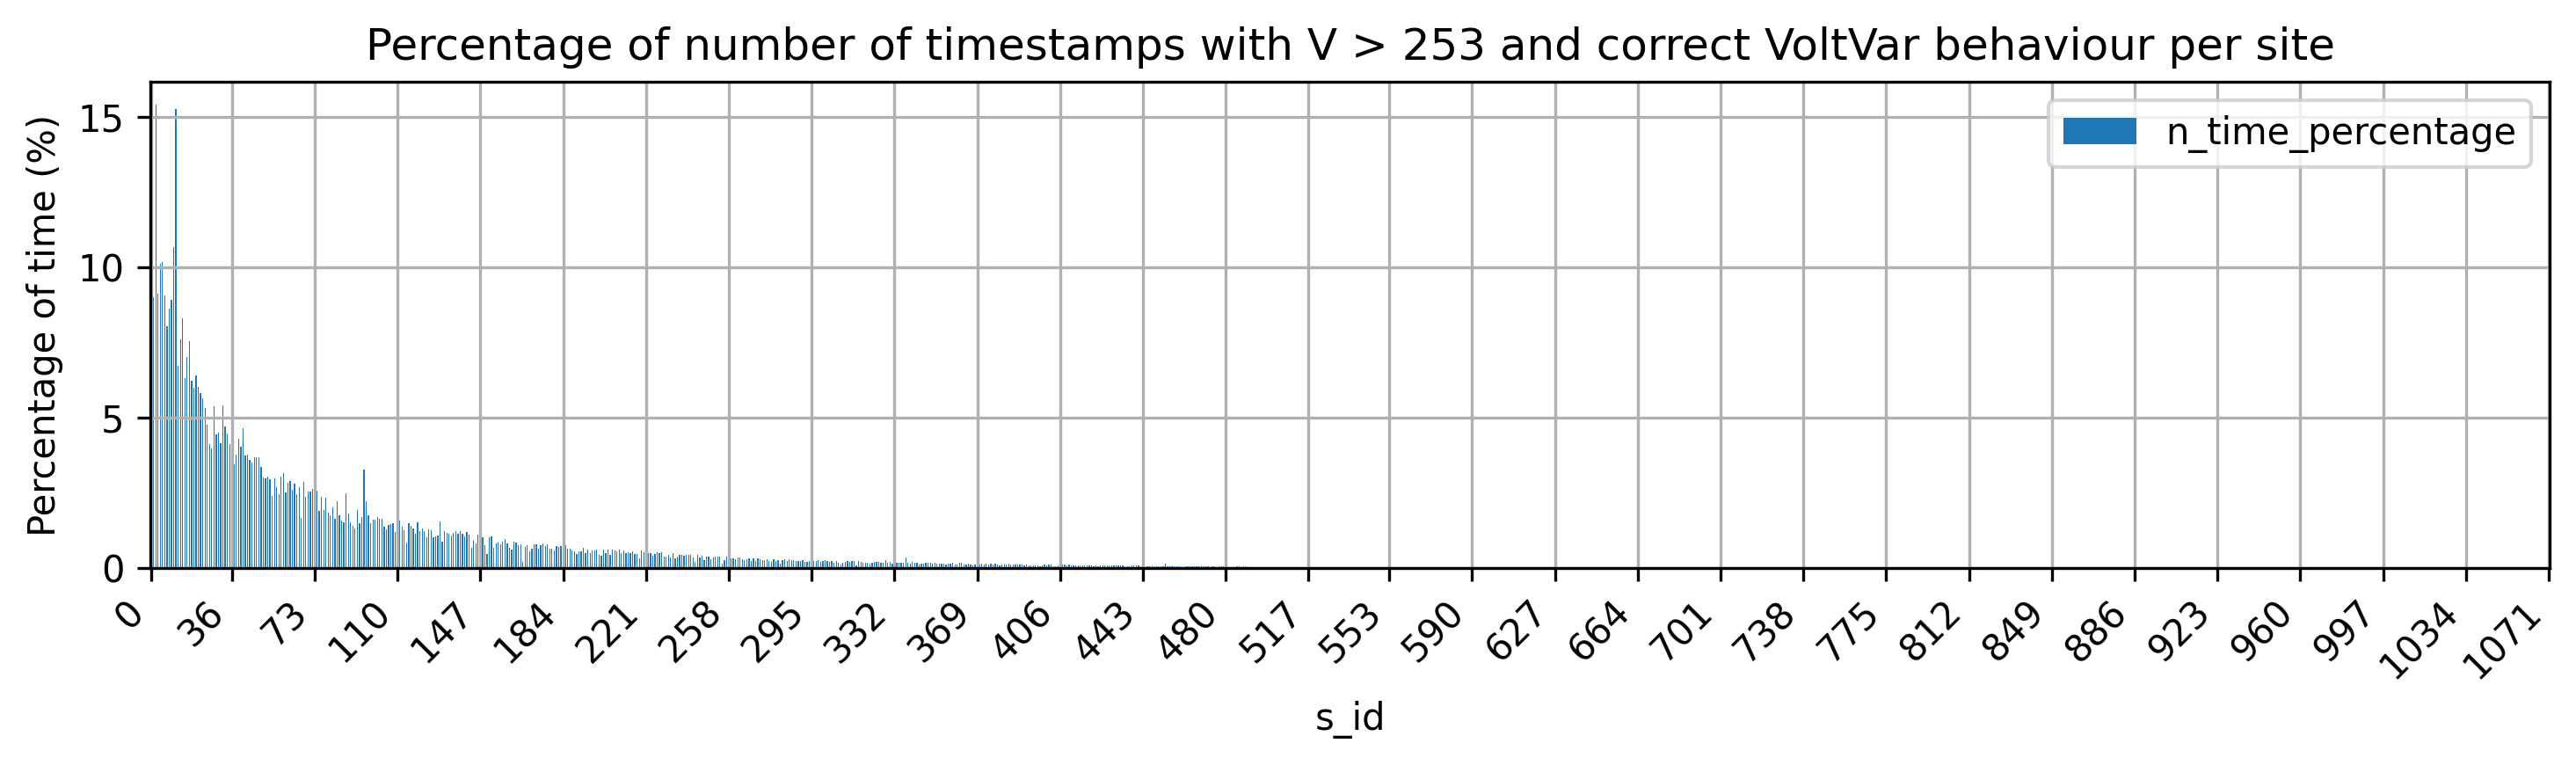

In [37]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)
df3.plot(
    kind='bar',
    ax=ax,
    x='s_id',
    y='n_time_percentage',
    title='Percentage of number of timestamps with V > 253 and correct VoltVar behaviour per site',
    ylabel='Percentage of time (%)',
)

# Set custom tick positions
xticks_positions = np.linspace(0, df3.shape[0]-1, 30, dtype=int)
ax.set_xticks(xticks_positions)

# Optionally label them (if you want specific site IDs)
ax.set_xticklabels(df3['s_id'].iloc[xticks_positions], rotation=45, ha='right')
plt.grid()
plt.tight_layout()
plt.show()

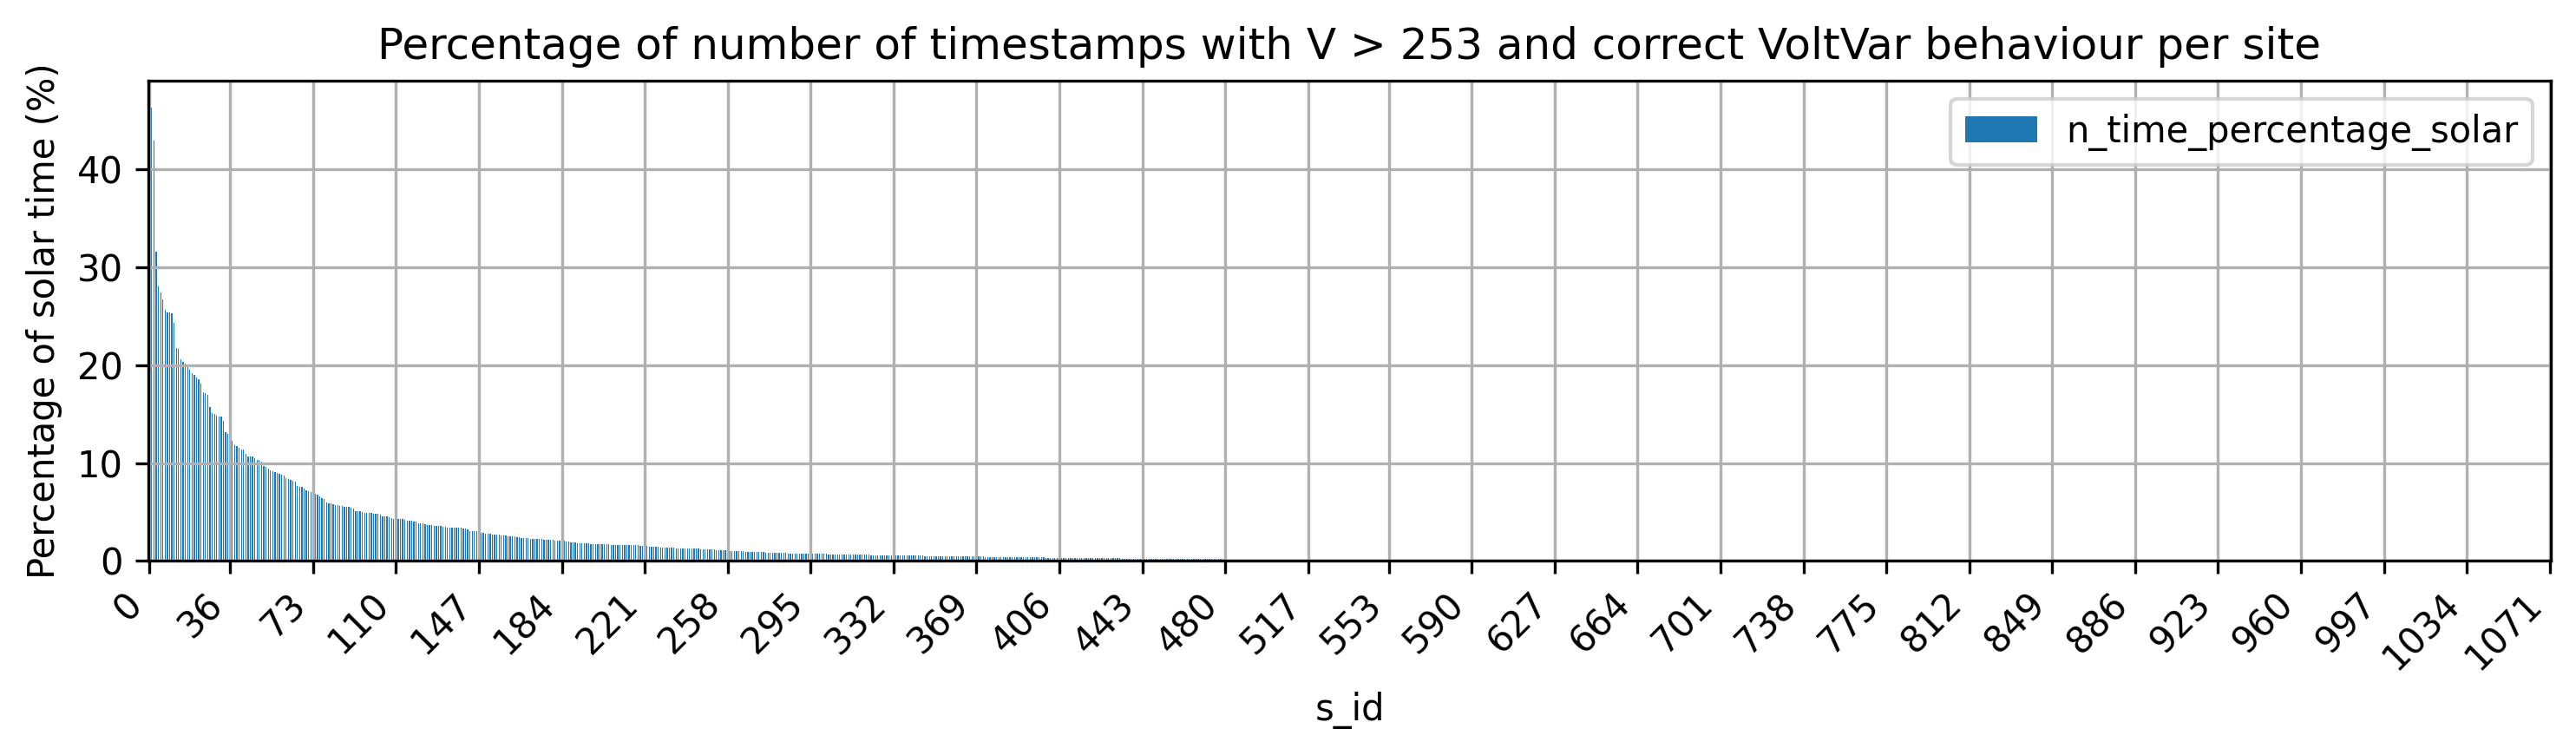

In [38]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)
df3.plot(
    kind='bar',
    ax=ax,
    x='s_id',
    y='n_time_percentage_solar',
    title='Percentage of number of timestamps with V > 253 and correct VoltVar behaviour per site',
    ylabel='Percentage of solar time (%)',
)

# Set custom tick positions
xticks_positions = np.linspace(0, df3.shape[0]-1, 30, dtype=int)
ax.set_xticks(xticks_positions)

# Optionally label them (if you want specific site IDs)
ax.set_xticklabels(df3['s_id'].iloc[xticks_positions], rotation=45, ha='right')
plt.grid()
plt.tight_layout()
plt.show()

$\frac{N.\,\text{of timestamps with}\, V>253 \,\&\, \text{V-Var conformance = 100\%}}
   {N.\,\text{of timestamps with}\, \text{PV > 16\%}}$

In [ ]:
iceberg_sql(f"""select  circuit_id, t_stamp
            from ts 
            where year=2024 and month=1 and is_pv=True 
            group by circuit_id, t_stamp
            having count(t_stamp) > 1
            limit 10
            """)


,circuit_id,t_stamp


In [4]:
np.sqrt(100 - 16)

np.float64(9.16515138991168)

In [5]:
iceberg_sql(f"""select *
            from ts 
            where year=2024 and month=10 and is_pv=True 
            and circuit_id = 373631 and t_stamp = TIMESTAMP '2024-10-16 01:20:00'
            """)


,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,voltage,current,year,month,is_pv,postcode
0,373631,2024-10-16 01:20:00,6904.5267,575.3772,13.1731,575.3772,0.0,13.1731,0.0,0.999476,242.4,30.338,2024,10,True,5244


In [45]:
hive_sql(f"""select *
            from ts 
            where year=2024 and month=10 and is_pv=True 
            and circuit_id = 373631 and t_stamp = TIMESTAMP '2024-10-16 01:20:00'
            """)


,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,voltage,current,year,month,is_pv
0,373631,2024-10-16 01:20:00,6904.5267,575.3772,13.1731,575.3772,0.0,13.1731,0.0,0.999476,242.4,30.338,2024,10,True


In [94]:
hive_sql(f"""select count( t_stamp) from ts where year=2024 and month=12 and is_pv=True limit 10""")


,_col0
0,352660646


In [75]:
iceberg_sql(f"""with data as (
                        select site_id, t_stamp, sum(power*circuit_polarity/1000) as P_kW, 
                            sum(energy_reactive*circuit_polarity/1000*12) as Q_kvar, 
                                avg(voltage) as V, ac_capacity_kw
                    from 
                    (select circuit_id, t_stamp, power, energy_reactive, voltage 
                    from ts where year=2024 and month=11 and is_pv=True and voltage > 0 and voltage < 300) as ts1
                    inner join meta_up23c as m on ts1.circuit_id = m.circuit_id
                    group by site_id, t_stamp, ac_capacity_kw)
                    select * from data limit 1000
                    """)

,site_id,t_stamp,P_kW,Q_kvar,V,ac_capacity_kw
0,1555410224,2024-11-30 23:35:00,2.895290,-0.442740,242.20,10.0
1,1555410224,2024-11-30 17:35:00,-0.004147,0.059066,241.75,10.0
2,1555410224,2024-11-30 15:15:00,-0.004130,0.060280,244.10,10.0
3,1555410224,2024-11-30 12:55:00,-0.004173,0.059630,242.85,10.0
4,1555410224,2024-11-30 05:15:00,5.620537,-1.619330,245.75,10.0
...,...,...,...,...,...,...
995,1555410224,2024-11-11 06:10:00,3.182053,-0.759553,243.25,10.0
996,1555410224,2024-11-11 03:10:00,5.209433,-1.774690,246.35,10.0
997,1555410224,2024-11-11 01:50:00,5.021500,-1.868400,245.60,10.0
998,1555410224,2024-11-11 00:30:00,5.280233,-1.912177,246.80,10.0


In [ ]:
iceberg_sql(f"""with data as (
                        select site_id, t_stamp, sum(power*circuit_polarity/1000) as P_kW, 
                            sum(energy_reactive*circuit_polarity/1000*12) as Q_kvar, 
                                avg(voltage) as V, ac_capacity_kw
                    from ts as ts1
                    inner join meta_up23c as m on ts1.circuit_id = m.circuit_id
                        where year=2024 and month=11 and ts1.is_pv=True and voltage > 0 and voltage < 300
                    group by site_id, t_stamp, ac_capacity_kw
                   )
                    select * from data limit 10
                    """)

,site_id,t_stamp,P_kW,Q_kvar,V,ac_capacity_kw
0,1555410224,2024-11-30 21:35:00,1.768553,-0.424880,241.65,10.0
1,1555410224,2024-11-30 20:35:00,0.784443,-0.189520,241.05,10.0
2,1555410224,2024-11-30 17:15:00,-0.004183,0.060497,244.55,10.0
3,1555410224,2024-11-30 12:15:00,-0.004193,0.059810,242.95,10.0
4,1555410224,2024-11-30 07:35:00,1.148700,0.082717,240.45,10.0
...,...,...,...,...,...,...
995,1555410224,2024-11-11 16:30:00,-0.004370,0.059200,241.70,10.0
996,1555410224,2024-11-11 14:50:00,-0.004410,0.060097,243.20,10.0
997,1555410224,2024-11-11 13:10:00,-0.004437,0.059113,241.65,10.0
998,1555410224,2024-11-11 05:10:00,6.672080,-1.785070,246.20,10.0


In [65]:
iceberg_sql("select * from meta_up23c limit 2")

,site_id,state,postcode,longitude,latitude,dnsp_name,dc_capacity_kw,ac_capacity_kw,export_limit_kw,monitoring_start,...,circuit_type,is_pv,min_time,max_time,v_95,v_05,m_id,n_long,n_lat,distance_km
0,1944472430,NSW,2502,150.85,-34.47,Endeavour,5.18,5.0,3.0,2021-08-09,...,pv_site_net,True,2024-07-23 04:45:00,2024-07-24 07:05:00,244.3,238.65,M43,150.84,-34.46,1.569777
1,1944472430,NSW,2502,150.85,-34.47,Endeavour,5.18,5.0,3.0,2021-08-09,...,ac_load_net,False,2024-07-23 04:45:00,2024-07-24 07:05:00,244.3,238.65,M43,150.84,-34.46,1.569777


In [18]:
iceberg_sql("""
            with data as (
                select ts.circuit_id, t_stamp, power as P_kW, 
                       energy_reactive*circuit_polarity/1000*12 as Q_kvar, voltage as V
            from ts left join meta_up23c as m on ts.circuit_id = m.circuit_id
            where year=2024 and month=1 and ts.is_pv=True and ts.circuit_id = 467634)
            select * from data order by t_stamp limit 10
            """)

,circuit_id,t_stamp,P_kW,Q_kvar,V
0,467634,2024-01-01 00:00:00,4473.9233,None,241.45
1,467634,2024-01-01 00:05:00,4523.3200,None,241.25
2,467634,2024-01-01 00:10:00,4535.8167,None,241.65
3,467634,2024-01-01 00:15:00,4589.9300,None,242.35
4,467634,2024-01-01 00:20:00,4619.6267,None,241.65
5,467634,2024-01-01 00:25:00,4716.0133,None,241.90
6,467634,2024-01-01 00:30:00,4767.7167,None,242.15
7,467634,2024-01-01 00:35:00,4758.5533,None,242.00
8,467634,2024-01-01 00:40:00,4803.2267,None,242.10
9,467634,2024-01-01 00:45:00,4833.1000,None,243.00


In [8]:
iceberg_sql("""
            select * from meta_up23c 
            limit 3
            """).columns

Index(['site_id', 'state', 'postcode', 'longitude', 'latitude', 'dnsp_name',
       'dc_capacity_kw', 'ac_capacity_kw', 'export_limit_kw',
       'monitoring_start', 'inverter_count', 'pv_install_date', 'manufacturer',
       'model', 'ac_capacity_kw_json', 'device_id', 'circuit_id',
       'device_type', 'circuit_polarity', 'circuit_type', 'is_pv', 'min_time',
       'max_time', 'v_95', 'v_05', 'v_99', 'v_01', 'voltage_class', 'm_id',
       'n_long', 'n_lat', 'distance_km'],
      dtype='object')